In [ ]:
# Install required packages.
# If your runtime already has these packages, this cell may finish quickly.
! pip install transformers datasets evaluate accelerate pillow torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00


# Image classification

Image classification assigns a label or class to an image. Unlike text or audio classification, the inputs are the
pixel values that comprise an image. There are many applications for image classification, such as detecting damage
after a natural disaster, monitoring crop health, or helping screen medical images for signs of disease.

This guide illustrates how to:

1. Fine-tune [ViT](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/vit) on the [Food-101](https://huggingface.co/datasets/ethz/food101) dataset to classify a food item in an image.
2. Use your fine-tuned model for inference.

<Tip>

To see all architectures and checkpoints compatible with this task, we recommend checking the [task-page](https://huggingface.co/tasks/image-classification)

</Tip>

Before you begin, make sure you have all the necessary libraries installed:

```bash
pip install transformers datasets evaluate accelerate pillow torchvision scikit-learn trackio
```

We encourage you to log in to your Hugging Face account to upload and share your model with the community. When prompted, enter your token to log in:

In [ ]:
# Optional: log in only if you want to download private models or push to the Hugging Face Hub.
# This homework does not require Hub login.
# from huggingface_hub import notebook_login
# notebook_login()


## Load Food-101 dataset

Start by loading a smaller subset of the Food-101 dataset from the 🤗 Datasets library. This will give you a chance to
experiment and make sure everything works before spending more time training on the full dataset.

In [ ]:
from datasets import load_dataset

food = load_dataset("ethz/food101", split="train[:5000]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/16.4k [00:00<?, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

...

data/validation-00000-of-00003.parquet:   0%|          | 0.00/423M [00:00<?, ?B/s]

data/validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

Split the dataset's `train` split into a train and test set with the [train_test_split](https://huggingface.co/docs/datasets/main/en/package_reference/main_classes#datasets.Dataset.train_test_split) method:

In [ ]:
food = food.train_test_split(test_size=0.2)

Then take a look at an example:

In [ ]:
food["train"][0]

{'image': <PIL.Image.Image image mode=RGB size=512x384>, 'label': 20}

Each example in the dataset has two fields:

- `image`: a PIL image of the food item
- `label`: the label class of the food item

To make it easier for the model to get the label name from the label id, create a dictionary that maps the label name
to an integer and vice versa:

In [ ]:
labels = food["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

Now you can convert the label id to a label name:

In [ ]:
id2label[str(79)]

'prime_rib'

---

# EE443 HW4 Problem 2: Vision Transformer Image Classification

In this notebook, you will fine-tune a pretrained Vision Transformer (ViT) for image classification on a small Food-101 subset. The data loading, train/test split, and label mapping above are already provided. **Do not change those cells.**

Your tasks are to complete the TODO code blocks, run the notebook end-to-end, and answer the reflection questions in your `hw4_ans.pdf`.

**Learning goals**

1. Understand how images are converted into normalized tensors for a pretrained ViT.
2. Fine-tune a pretrained transformer backbone for image classification.
3. Evaluate the trained model with accuracy and qualitative examples.
4. Reflect on common failure cases and the difference between CNN-style inductive bias and transformer-style patch attention.


## 0. Sanity check and dataset reflection

Run the following cells to inspect the current dataset. This section should help you verify that the provided data-loading part worked correctly.

**Reflection question for PDF:** Why is it useful to start with a small subset such as `train[:5000]` before training on the full Food-101 dataset?


In [ ]:
# TODO 0: Print basic dataset information.
# Fill in the blanks so that the output shows the train size, test size, and number of classes.

num_train = len(food["train"])
num_test = len(food["test"])
num_classes = len(labels)

print(f"Number of training examples: {num_train}")
print(f"Number of test examples: {num_test}")
print(f"Number of classes: {num_classes}")
print("First 10 class names:", labels[:10])


Number of training examples: 4000
Number of test examples: 1000
Number of classes: 101
First 10 class names: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


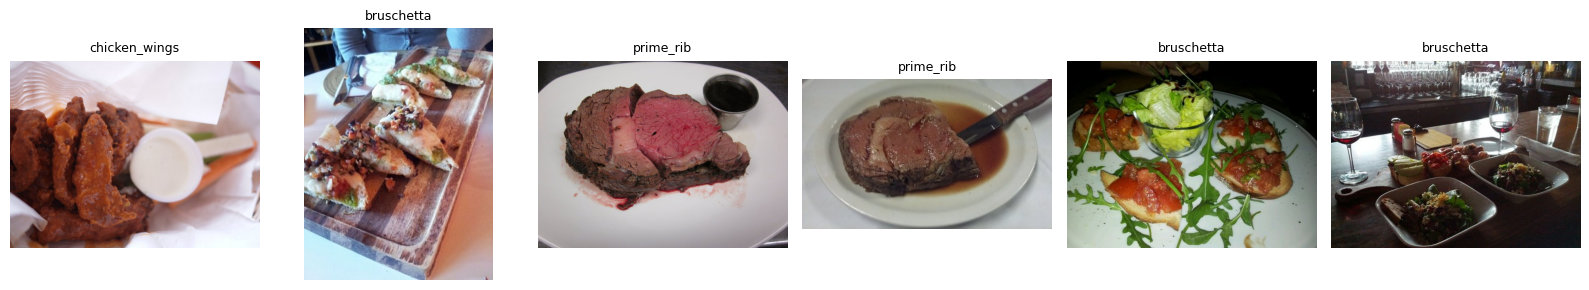

In [ ]:
# TODO 0b: Visualize a few examples from the training split.
# Hint: each example has fields 'image' and 'label'. Use id2label[str(label_id)] to get the class name.

import matplotlib.pyplot as plt

num_examples_to_show = 6
fig, axes = plt.subplots(1, num_examples_to_show, figsize=(16, 3))

for i in range(num_examples_to_show):
    example = food["train"][i]
    image = example["image"]
    label_id = example["label"]
    label_name = id2label[str(label_id)]
    axes[i].imshow(image)
    axes[i].set_title(label_name, fontsize=9)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 1. Preprocessing for ViT

A pretrained ViT expects images to be resized/cropped and normalized in the same way as its pretraining setup. In this section, you will load the image processor and define data transformations.

**Reflection question for PDF:** What could go wrong if the normalization mean and standard deviation do not match the pretrained model's expected preprocessing?


In [ ]:
from transformers import AutoImageProcessor

checkpoint = "google/vit-base-patch16-224-in21k"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

print("Image processor size:", image_processor.size)
print("Image mean:", image_processor.image_mean)
print("Image std:", image_processor.image_std)


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Image processor size: {'height': 224, 'width': 224}
Image mean: [0.5, 0.5, 0.5]
Image std: [0.5, 0.5, 0.5]


In [ ]:
# TODO 1: Define train and validation transforms.
# Requirements:
# - Use the mean and std from image_processor.
# - For training, use RandomResizedCrop followed by ToTensor and Normalize.
# - For validation, use Resize, CenterCrop, ToTensor, and Normalize.

from torchvision.transforms import Compose, Normalize, ToTensor, RandomResizedCrop, Resize, CenterCrop

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)

size = (
    image_processor.size["shortest_edge"]
    if "shortest_edge" in image_processor.size
    else image_processor.size["height"]
)

train_transforms = Compose([
    RandomResizedCrop(size),
    ToTensor(),
    normalize,
])

eval_transforms = Compose([
    Resize(size),
    CenterCrop(size),
    ToTensor(),
    normalize,
])


In [ ]:
# TODO 2: Write transform functions for train and validation examples.
# Each function should:
# 1. Convert each PIL image to RGB.
# 2. Apply the correct transform pipeline.
# 3. Store the tensor list in examples["pixel_values"].
# 4. Remove examples["image"] so the Trainer receives tensors instead of raw images.


def apply_train_transforms(examples):
    examples["pixel_values"] = [train_transforms(img.convert("RGB")) for img in examples["image"]]
    del examples["image"]
    return examples


def apply_eval_transforms(examples):
    examples["pixel_values"] = [eval_transforms(img.convert("RGB")) for img in examples["image"]]
    del examples["image"]
    return examples


train_ds = food["train"].with_transform(apply_train_transforms)
eval_ds = food["test"].with_transform(apply_eval_transforms)


In [ ]:
# TODO 2b: Inspect one transformed example.
# Expected: pixel_values should be a tensor of shape [3, H, W].

sample = train_ds[0]
print(sample.keys())
print("pixel_values shape:", sample["pixel_values"].shape)
print("label:", sample["label"])
print("label name:", id2label[str(sample["label"])])


dict_keys(['label', 'pixel_values'])
pixel_values shape: torch.Size([3, 224, 224])
label: 20
label name: chicken_wings


## 2. Evaluation metric

For this assignment, you will use classification accuracy. You may also print a confusion matrix later for error analysis, but accuracy is the required metric.

**Reflection question for PDF:** Is accuracy always a sufficient metric for image classification? Explain one situation where accuracy may be misleading.


In [ ]:
# TODO 3: Implement compute_metrics.
# Hint: eval_pred contains logits and labels. Convert logits to predicted class IDs using np.argmax.

import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")


def compute_metrics(eval_pred):
    logits, references = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy.compute(predictions=predictions, references=references)


## 3. Load the pretrained ViT model

You will now load a pretrained ViT backbone and replace its classification head for Food-101.

**Reflection question for PDF:** Which part of the model is pretrained, and which part is newly initialized for this classification task?


In [ ]:
# TODO 4: Load AutoModelForImageClassification.
# Requirements:
# - Use checkpoint defined above.
# - Set num_labels to the number of Food-101 classes.
# - Pass id2label and label2id.

from transformers import AutoModelForImageClassification

model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
)

print(model.config.num_labels)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


101


## 4. Fine-tuning setup

Complete the training configuration and construct a Hugging Face `Trainer`. For this homework notebook, you do **not** need to push the model to the Hugging Face Hub.

**Reflection question for PDF:** How would increasing the batch size, learning rate, or number of epochs affect training time and possible overfitting?


In [ ]:
# TODO 5: Define TrainingArguments.
# Suggested settings for a short homework run:
# - learning_rate: 5e-5
# - per_device_train_batch_size: 16
# - per_device_eval_batch_size: 16
# - num_train_epochs: 2 or 3
# - eval_strategy and save_strategy: "epoch"
# - remove_unused_columns: False
# - push_to_hub: False

from transformers import TrainingArguments, Trainer, DefaultDataCollator

training_args = TrainingArguments(
    output_dir="hw4_food101_vit_model",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
    report_to="none",
)

data_collator = DefaultDataCollator()


In [ ]:
# TODO 6: Create the Trainer.
# Make sure to use train_ds and eval_ds, not the original raw dataset.

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=image_processor,
    compute_metrics=compute_metrics,
)


In [ ]:
# Train the model.
# This may take some time depending on your GPU/Colab runtime.

train_result = trainer.train()
print(train_result)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.066118,1.002768,0.917000
2,0.647747,0.546863,0.926000
3,0.423477,0.422741,0.953000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=750, training_loss=1.1007593653996786, metrics={'train_runtime': 558.7969, 'train_samples_per_second': 21.475, 'train_steps_per_second': 1.342, 'total_flos': 9.307289843712e+17, 'train_loss': 1.1007593653996786, 'epoch': 3.0})


In [ ]:
# TODO 7: Evaluate the trained model and report the result.
# Save the evaluation dictionary because you will need it in the PDF summary.

eval_results = trainer.evaluate()
print(eval_results)


{'eval_loss': 0.42274072766304016, 'eval_accuracy': 0.953, 'eval_runtime': 16.3532, 'eval_samples_per_second': 61.15, 'eval_steps_per_second': 3.852, 'epoch': 3.0}


## 5. Inference and qualitative visualization

In this section, you will run the trained model on validation images and visualize correct or incorrect predictions.

**Reflection question for PDF:** Choose at least two examples and discuss why the model may classify them correctly or incorrectly. Consider visual similarity, ambiguity, cropping, and dataset labels.


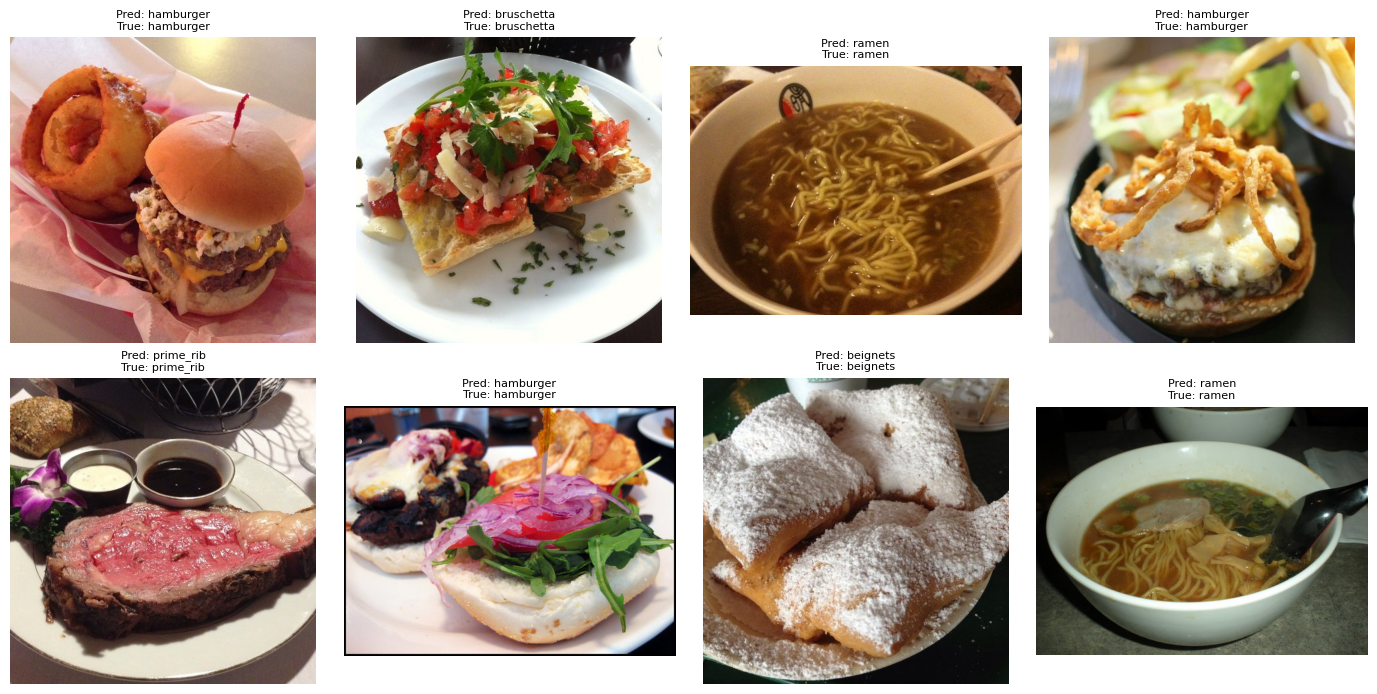

In [ ]:
# TODO 8: Run inference on a few validation examples and visualize predictions.

import torch

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

raw_eval_ds = food["test"]
num_examples_to_show = 8
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for i in range(num_examples_to_show):
    example = raw_eval_ds[i]
    image = example["image"].convert("RGB")
    true_label_id = example["label"]
    true_label_name = id2label[str(true_label_id)]

    inputs = image_processor(image, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    pred_label_id = int(torch.argmax(logits, dim=-1).item())
    pred_label_name = id2label[str(pred_label_id)]

    axes[i].imshow(image)
    axes[i].set_title(f"Pred: {pred_label_name}\nTrue: {true_label_name}", fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# TODO 9: Find a few misclassified examples from the validation split.
# Fill in the missing parts. Limit the search to the first N examples to keep runtime reasonable.

N = 100
misclassified = []

for i in range(min(N, len(raw_eval_ds))):
    example = raw_eval_ds[i]
    image = example["image"].convert("RGB")
    true_label_id = example["label"]

    inputs = image_processor(image, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits

    pred_label_id = int(torch.argmax(logits, dim=-1).item())
    if pred_label_id != true_label_id:
        misclassified.append((i, pred_label_id, true_label_id))

print(f"Found {len(misclassified)} misclassified examples among the first {N} validation examples.")
print("First 10 mistakes:")
for idx, pred, true in misclassified[:10]:
    print(f"index={idx:3d} | pred={id2label[str(pred)]} | true={id2label[str(true)]}")


Found 2 misclassified examples among the first 100 validation examples.
First 10 mistakes:
index= 23 | pred=pork_chop | true=prime_rib
index= 74 | pred=beignets | true=prime_rib


## 6. Short written answers for `hw4_ans.pdf`

Answer the following questions in your PDF. You may write your draft answers below first.

1. Report your final training loss if available and final validation accuracy.
2. Include a few correctly classified and incorrectly classified images.
3. Explain why ViT splits an image into patches before applying self-attention.
4. Compare one strength of ViT with one strength of CNNs for image classification.
5. Describe one limitation of your experiment. Examples include small data subset, limited training epochs, class imbalance, random crop effects, or limited GPU budget.


In [ ]:
# Optional student notes cell:
# Write down the final values and observations you plan to include in hw4_ans.pdf.

final_validation_accuracy = None
main_observation = ""
most_common_failure_case = ""
